<a href="https://colab.research.google.com/github/subharthiii/virtualTryOn-SDXL/blob/main/virtualtryon_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 👗 Virtual Try-On — SDXL + IP-Adapter

Upload a **model image** and a **clothing image**, and this notebook will generate a realistic photo of the model wearing that clothing.

**How it works:**
1. Segments the human body using SegFormer
2. Detects and preserves the face using InsightFace
3. Uses SDXL Inpainting + IP-Adapter to virtually dress the model

---
⚠️ **Before running:** Go to `Runtime > Change runtime type` and set Hardware Accelerator to **GPU (T4)**.

In [1]:
# ── Cell 1: Install dependencies ──────────────────────────────────────────────
!pip install -q diffusers accelerate insightface onnxruntime-gpu transformers
print("✅ Dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 762.2/762.2 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 68.9 MB/s eta 0:00:00
✅ Dependencies installed


In [2]:
# ── Cell 2: Check GPU ─────────────────────────────────────────────────────────
import torch

if not torch.cuda.is_available():
    raise RuntimeError("❌ No GPU detected. Go to Runtime > Change runtime type and select GPU.")

print(f"✅ GPU ready: {torch.cuda.get_device_name(0)}")
print(f"   VRAM available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✅ GPU ready: Tesla T4
   VRAM available: 15.6 GB


In [3]:
# ── Cell 3: Imports ───────────────────────────────────────────────────────────
import numpy as np
import torch
import torch.nn as nn
from PIL import Image, ImageDraw
from IPython.display import display
import insightface
from insightface.app import FaceAnalysis
from diffusers import AutoPipelineForInpainting, AutoencoderKL
from diffusers.utils import load_image
from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation

print("✅ Imports done")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.


✅ Imports done


📂 Upload your MODEL image (photo of the person):


Saving modelM2.jpg to modelM2.jpg

📂 Upload your CLOTHING image (the garment you want to try on):


Saving menTopWear2.jpg to menTopWear2.jpg

🧍 Model image:


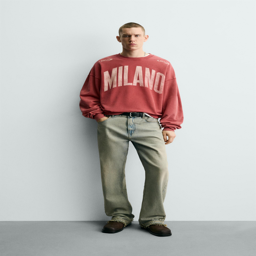


👕 Clothing image:


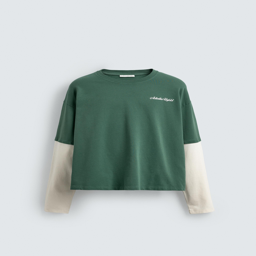

In [16]:
# ── Cell 4: Upload your images ────────────────────────────────────────────────
# Upload a photo of the model (person) and a photo of the clothing item.

from google.colab import files

print("📂 Upload your MODEL image (photo of the person):")
uploaded_model = files.upload()
model_filename = list(uploaded_model.keys())[0]

print("\n📂 Upload your CLOTHING image (the garment you want to try on):")
uploaded_clothing = files.upload()
clothing_filename = list(uploaded_clothing.keys())[0]

# Load images
model_image    = Image.open(model_filename).convert("RGB")
clothing_image = Image.open(clothing_filename).convert("RGB")

# Preview
print("\n🧍 Model image:")
display(model_image.resize((256, 256)))
print("\n👕 Clothing image:")
display(clothing_image.resize((256, 256)))

In [5]:
# ── Cell 5: Load segmentation model ──────────────────────────────────────────
# Using the official SegFormer API instead of the pipeline wrapper (more reliable)

print("Loading SegFormer clothes segmentation model...")
seg_processor = SegformerImageProcessor.from_pretrained("mattmdjaga/segformer_b2_clothes")
seg_model     = AutoModelForSemanticSegmentation.from_pretrained("mattmdjaga/segformer_b2_clothes")
seg_model.eval()
print("✅ Segmentation model loaded")

# Label map from the model card
LABEL_MAP = {
    0:  "Background",  1:  "Hat",         2:  "Hair",
    3:  "Sunglasses",  4:  "Upper-clothes",5:  "Skirt",
    6:  "Pants",       7:  "Dress",        8:  "Belt",
    9:  "Left-shoe",   10: "Right-shoe",   11: "Face",
    12: "Left-leg",    13: "Right-leg",    14: "Left-arm",
    15: "Right-arm",   16: "Bag",          17: "Scarf"
}

Loading SegFormer clothes segmentation model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.73k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/109M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

✅ Segmentation model loaded


In [6]:
# ── Cell 6: Load face detection model ────────────────────────────────────────
print("Loading InsightFace...")
face_app = FaceAnalysis(providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
face_app.prepare(ctx_id=0, det_size=(640, 640))
print("✅ Face detection loaded")

Loading InsightFace...
download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:02<00:00, 99342.30KB/s]
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:149: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
✅ Face detec

In [7]:
# ── Cell 7: Segmentation helpers ──────────────────────────────────────────────

def get_segmentation_map(image: Image.Image) -> np.ndarray:
    """Run SegFormer and return a per-pixel label map (H x W)."""
    inputs  = seg_processor(images=image, return_tensors="pt")
    with torch.no_grad():
        outputs = seg_model(**inputs)
    logits = outputs.logits  # (1, num_labels, H/4, W/4)
    upsampled = nn.functional.interpolate(
        logits,
        size=image.size[::-1],   # (H, W)
        mode="bilinear",
        align_corners=False,
    )
    return upsampled.argmax(dim=1)[0].cpu().numpy()  # (H, W)


def labels_to_mask(seg_map: np.ndarray, include_labels: list) -> Image.Image:
    """Build a binary PIL mask from a list of label names."""
    label_ids = [k for k, v in LABEL_MAP.items() if v in include_labels]
    binary    = np.zeros_like(seg_map, dtype=np.uint8)
    for lid in label_ids:
        binary[seg_map == lid] = 255
    return Image.fromarray(binary)


def remove_face_from_mask(image: Image.Image, mask: Image.Image) -> Image.Image:
    """Black-out the face region in the mask so inpainting doesn't touch it."""
    img_np = np.array(image.convert("RGB"))
    faces  = face_app.get(img_np)
    if not faces:
        print("⚠️  No face detected — skipping face removal.")
        return mask

    bbox = faces[0]["bbox"].copy()  # [x1, y1, x2, y2]
    w    = bbox[2] - bbox[0]
    h    = bbox[3] - bbox[1]

    # Expand bounding box slightly so hair/neck are preserved
    bbox[0] -= w * 0.5
    bbox[2] += w * 0.5
    bbox[1] -= h * 0.5
    bbox[3] += h * 0.2

    draw = ImageDraw.Draw(mask)
    draw.rectangle([(bbox[0], bbox[1]), (bbox[2], bbox[3])], fill=0)
    return mask


def build_torso_mask(image: Image.Image) -> Image.Image:
    """Return a mask covering upper-body clothing area (excludes face)."""
    seg_map = get_segmentation_map(image)
    torso_labels = ["Upper-clothes", "Dress", "Belt", "Left-arm", "Right-arm"]
    mask = labels_to_mask(seg_map, torso_labels)
    mask = remove_face_from_mask(image, mask)
    return mask


print("✅ Segmentation helpers ready")

✅ Segmentation helpers ready


Generating clothing mask...

🗺️  Segmentation mask (white = region to replace):


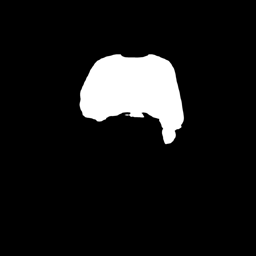

In [17]:
# ── Cell 8: Generate and preview the mask ─────────────────────────────────────
print("Generating clothing mask...")
mask_image = build_torso_mask(model_image)

# Resize to 1024x1024 — SDXL native resolution
TARGET_SIZE = (1024, 1024)
model_image_resized = model_image.resize(TARGET_SIZE)
mask_image_resized  = mask_image.resize(TARGET_SIZE)

print("\n🗺️  Segmentation mask (white = region to replace):")
display(mask_image_resized.resize((256, 256)))

In [10]:
# ── Cell 9: Load SDXL pipeline ────────────────────────────────────────────────
# This downloads ~6 GB — takes a few minutes on first run.

print("Loading VAE...")
vae = AutoencoderKL.from_pretrained(
    "madebyollin/sdxl-vae-fp16-fix",
    torch_dtype=torch.float16,
)

print("Loading SDXL Inpainting pipeline...")
pipe = AutoPipelineForInpainting.from_pretrained(
    "diffusers/stable-diffusion-xl-1.0-inpainting-0.1",
    vae=vae,
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True,
).to("cuda")

print("Loading IP-Adapter...")
pipe.load_ip_adapter(
    "h94/IP-Adapter",
    subfolder="sdxl_models",
    weight_name="ip-adapter_sdxl.bin",
)
pipe.set_ip_adapter_scale(0.9)   # 0.9 = strong clothing fidelity, some flexibility

# Optional: speed up with xformers if available
try:
    pipe.enable_xformers_memory_efficient_attention()
    print("⚡ xformers enabled")
except Exception:
    pass

print("✅ Pipeline ready")

Loading VAE...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/631 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading SDXL Inpainting pipeline...


...

sdxl_models/ip-adapter_sdxl.bin:   0%|          | 0.00/703M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.01k [00:00<?, ?B/s]

sdxl_models/image_encoder/model.safetens(…):   0%|          | 0.00/3.69G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/776 [00:00<?, ?it/s]

✅ Pipeline ready


I took this out of the cell 9, for times i need to change the ip_adapter_scale


In [20]:
pipe.set_ip_adapter_scale(1.0)  # 0 to 1 — higher = clothing more faithfully copied

In [21]:
# ── Cell 10: Run try-on generation ───────────────────────────────────────────
# Tune these parameters if results aren't what you want:
#   strength        → higher = more creative but deviates more from original body
#   guidance_scale  → higher = sticks closer to the text prompt
#   num_steps       → more = better quality but slower (50 is a good balance)
#   ip_adapter_scale (set above) → higher = clothing image is more faithfully preserved

PROMPT = (
    "photorealistic, high quality photo, natural skin, "
    "person wearing the clothing, consistent lighting"
)
NEGATIVE_PROMPT = (
    "ugly, low quality, deformed, bad anatomy, bad hands, "
    "blurry, cartoon, painting, extra limbs, watermark"
)

print("🎨 Generating try-on result...")
generator = torch.Generator(device="cuda").manual_seed(42)  # change seed for variation

result = pipe(
    prompt           = PROMPT,
    negative_prompt  = NEGATIVE_PROMPT,
    image            = model_image_resized,
    mask_image       = mask_image_resized,
    ip_adapter_image = clothing_image,
    strength         = 0.70,
    guidance_scale   = 9.0,
    num_inference_steps = 50,
    generator        = generator,
).images[0]

print("✅ Done!")

🎨 Generating try-on result...


  0%|          | 0/41 [00:00<?, ?it/s]

✅ Done!


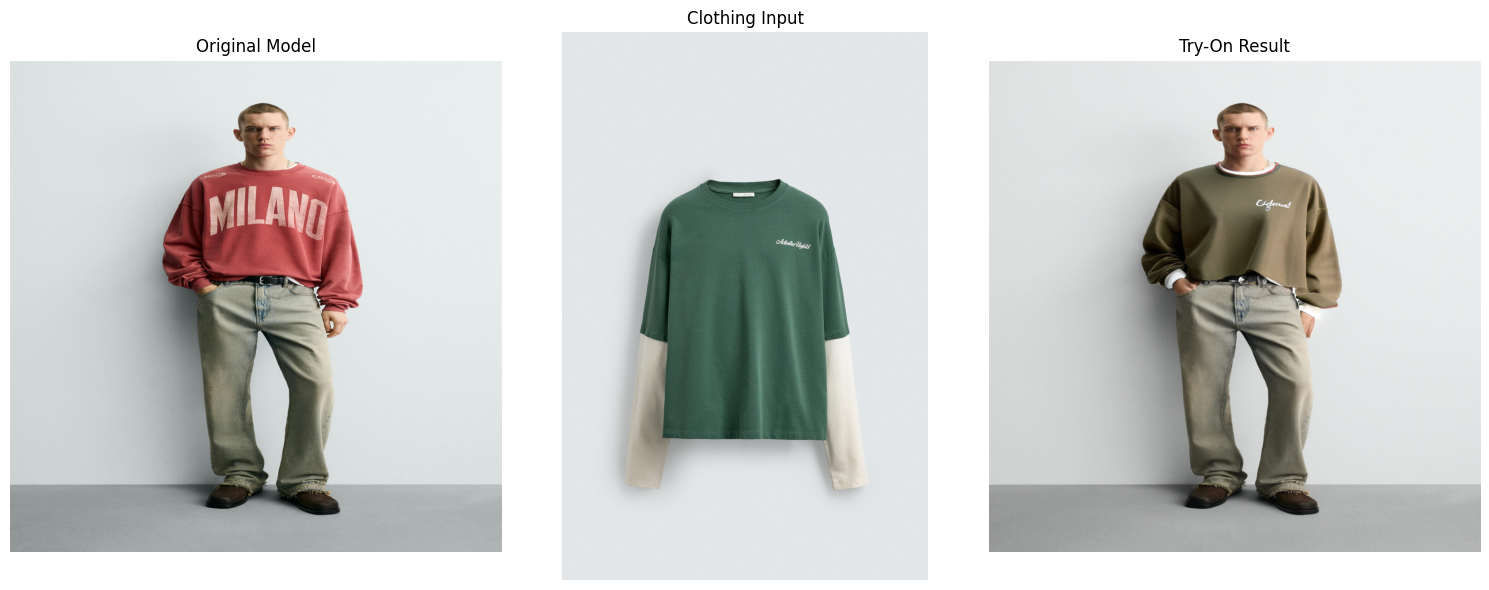

💾 Saved: tryon_result.jpg & tryon_comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
# ── Cell 11: View and save result ─────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
axes[0].imshow(model_image_resized);    axes[0].set_title("Original Model");    axes[0].axis("off")
axes[1].imshow(clothing_image);         axes[1].set_title("Clothing Input");    axes[1].axis("off")
axes[2].imshow(result);                 axes[2].set_title("Try-On Result");     axes[2].axis("off")
plt.tight_layout()
plt.savefig("tryon_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

result.save("tryon_result.jpg", quality=95)
print("💾 Saved: tryon_result.jpg & tryon_comparison.png")

# Download to your machine
from google.colab import files
files.download("tryon_result.jpg")
files.download("tryon_comparison.png")

## 🔧 Troubleshooting

| Problem | Fix |
|---|---|
| CUDA out of memory | Reduce `num_inference_steps` to 30, or restart runtime |
| Clothing not showing correctly | Increase `ip_adapter_scale` to 1.0 or reduce `strength` to 0.85 |
| Face looks distorted | The face mask isn't working — check InsightFace detected a face in Cell 8 |
| Too slow | Use Colab Pro for A100 GPU — T4 takes ~3 min at 50 steps |